# Classement par le modèle Bradley-Terry 

Modèle de Bradley-Terry:
P(i bat j) = βᵢ / (βᵢ + βⱼ)
où βᵢ est le paramètre de « force créative » du modèle i, estimé par maximum de vraisemblance. Les ex-æquo (both_equal = True) peuvent être gérés par l’extension Davidson (1970).

## Préparation dataset

In [1]:
from pathlib import Path
import pandas as pd
# This gets the directory where your notebook/script is located
base_dir = Path.cwd() 

# Build the path safely
file_path = base_dir.parent / "data" / "comparia-votes" / "votes.jsonl"

# Read the file
df_votes = pd.read_json(file_path, lines=True)

In [2]:
df_votes.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",NaN,crée des cartes types dixit sur le thème des m...,1.0,"[{'role': 'user', 'content': 'crée des cartes ...","[{'role': 'user', 'content': 'crée des cartes ...",...,False,False,False,False,False,False,NaN,NaN,False,False
1,55251,2025-04-22 18:07:44.914,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,0.0,"[{'role': 'user', 'content': 'J'ai lu quelque ...","[{'role': 'user', 'content': 'J'ai lu quelque ...",...,False,False,False,True,False,False,NaN,NaN,True,False
2,56377,2025-04-28 08:47:19.683,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",NaN,créer un texte sur le degrés d'intégration des...,1.0,"[{'role': 'user', 'content': 'créer un texte s...","[{'role': 'user', 'content': 'créer un texte s...",...,False,False,False,False,False,False,NaN,NaN,False,False
3,64275,2025-05-17 05:45:36.035,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,0.0,"[{'role': 'user', 'content': 'Coucou '}, {'rol...","[{'role': 'user', 'content': 'Coucou '}, {'rol...",...,False,False,False,False,False,False,NaN,NaN,False,False
4,30173,2025-02-24 15:05:34.404,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,0.0,"[{'role': 'system', 'content': 'Tu es un assis...","[{'role': 'user', 'content': 'Je souhaite élab...",...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False


In [3]:
df_votes.columns

Index(['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name',
       'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a',
       'conversation_b', 'conv_turns', 'selected_category',
       'is_unedited_prompt', 'conversation_pair_id', 'session_hash',
       'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a',
       'conv_useful_b', 'conv_creative_a', 'conv_creative_b',
       'conv_clear_formatting_a', 'conv_clear_formatting_b',
       'conv_incorrect_a', 'conv_incorrect_b', 'conv_superficial_a',
       'conv_superficial_b', 'conv_instructions_not_followed_a',
       'conv_instructions_not_followed_b', 'system_prompt_b',
       'system_prompt_a', 'conv_complete_a', 'conv_complete_b'],
      dtype='str')

In [4]:
df_votes.isnull().sum()

id                                       0
timestamp                                0
model_a_name                             0
model_b_name                             0
model_pair_name                          0
chosen_model_name                    52566
opening_msg                              0
both_equal                           13622
conversation_a                           0
conversation_b                           0
conv_turns                               0
selected_category                   146934
is_unedited_prompt                       0
conversation_pair_id                     0
session_hash                             0
visitor_id                               0
conv_comments_a                          0
conv_comments_b                          0
conv_useful_a                            0
conv_useful_b                            0
conv_creative_a                          0
conv_creative_b                          0
conv_clear_formatting_a                  0
conv_clear_

In [5]:
df_votes.shape

(157132, 34)

In [6]:
df_votes["selected_category"].value_counts()

selected_category
explanations           2152
ideas                  1528
iasummit               1292
recipes                 998
stories                 958
recommendations         878
administrative          865
coach                   748
languages               449
unguided                 96
expression               77
vie-professionnelle      44
conseils                 33
langues                  27
loisirs                  21
administratif            16
summaries                 9
regional                  6
slang                     1
Name: count, dtype: int64

les colones qui nous intéressent sont :
- model_a_name : le nom du modèle A
- model_b_name : le nom du modèle B
- chosen_model_name : le modèle choisi par le juge
- both_equal : indique si les deux modèles sont jugés égaux
- conv_creative_a: la conversation associée au modèle A est elle créative ou non
- conv_creative_b: la conversation associée au modèle B est elle créative ou non

In [7]:
df_votes_good_columns = df_votes[["model_a_name", "model_b_name", "chosen_model_name", "both_equal", "conv_creative_a", "conv_creative_b"]]
df_votes_good_columns.head()

,model_a_name,model_b_name,chosen_model_name,both_equal,conv_creative_a,conv_creative_b
0,gemini-2.5-flash,grok-4-fast,NaN,1.0,False,False
1,gemma-3-4b,c4ai-command-r-08-2024,gemma-3-4b,0.0,False,False
2,phi-4,llama-3.1-405b,NaN,1.0,False,False
3,phi-4,gemma-3-27b,gemma-3-27b,0.0,False,False
4,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,gpt-4o-2024-08-06,0.0,False,False


Maintenant netoyons les données pour ne garder que les colonnes qui nous intéressent et vérifier qu’il n’y a pas de valeurs manquantes.

In [8]:
df_votes_good_columns.isnull().sum()

model_a_name             0
model_b_name             0
chosen_model_name    52566
both_equal           13622
conv_creative_a          0
conv_creative_b          0
dtype: int64

On voit que l'on a des valeurs manquantes dans les colones chosen_model_name et both_eaqual, regardons si both_equal est null lorsque chosen_model_name n'est pas null et vice versa pour comprendre la nature de ces valeurs manquantes.

In [9]:
# vérifier si il ya des lignes où both equal est null et chosen_model_name est null
df_votes_good_columns[(df_votes_good_columns["both_equal"].isnull()) & (df_votes_good_columns["chosen_model_name"].isnull())]

,model_a_name,model_b_name,chosen_model_name,both_equal,conv_creative_a,conv_creative_b
367,mixtral-8x7b-instruct-v0.1,lfm-40b,NaN,NaN,False,False
1136,llama-3.1-8b,phi-3.5-mini-instruct,NaN,NaN,False,False
1546,phi-3.5-mini-instruct,llama-3.1-405b,NaN,NaN,False,False
1576,llama-3.1-70b,llama-3.1-405b,NaN,NaN,False,False
1741,gemma-2-9b-it,mixtral-8x22b-instruct-v0.1,NaN,NaN,False,False
...,...,...,...,...,...,...
114446,gemini-1.5-pro,chocolatine-14b-instruct-dpo-v1.2-q4,NaN,NaN,False,False
114447,gemini-1.5-pro,chocolatine-14b-instruct-dpo-v1.2-q4,NaN,NaN,False,False
114448,gemini-1.5-pro,chocolatine-14b-instruct-dpo-v1.2-q4,NaN,NaN,True,False
114451,gemini-1.5-pro,gemma-2-27b-it-q8,NaN,NaN,False,False


In [10]:
df_votes_good_columns[(df_votes_good_columns["both_equal"].isnull()) & (df_votes_good_columns["chosen_model_name"].isnull())].shape

(3995, 6)

On a 21 lignes où both_equal est null et chosen_model_name est null, il s'agit probablement de lignes où le juge n'a rien dit sur ses préférences donc on va supprimer ces lignes.

In [11]:

df_votes_good_columns_first_clean = df_votes_good_columns.dropna(subset=["both_equal", "chosen_model_name"], how="all")

In [12]:
df_votes_good_columns_first_clean.isnull().sum()

model_a_name             0
model_b_name             0
chosen_model_name    48571
both_equal            9627
conv_creative_a          0
conv_creative_b          0
dtype: int64

In [13]:
df_votes_good_columns_first_clean["both_equal"].value_counts()

both_equal
0.0    94939
1.0    48571
Name: count, dtype: int64

regardons les vaeleurs de chosen_model_name quand both_equal est null pour voir si il ya des anomalies.

In [14]:
df_votes_good_columns_first_clean[df_votes_good_columns_first_clean["both_equal"].isnull()]["chosen_model_name"].value_counts(dropna=False)

chosen_model_name
gemini-1.5-pro                          1400
llama-3.1-405b                          1249
llama-3.1-70b                           1013
gemma-2-9b-it                            737
phi-3.5-mini-instruct                    726
mixtral-8x7b-instruct-v0.1               674
mistral-nemo-2407                        658
ministral-8b-instruct-2410               535
qwen2.5-7b-instruct                      481
llama-3.1-8b                             404
mixtral-8x22b-instruct-v0.1              373
gemma-2-27b-it-q8                        316
lfm-40b                                  269
gpt-4o-mini-2024-07-18                   170
hermes-3-llama-3.1-405b                  139
gpt-4o-2024-08-06                        121
llama-3.1-nemotron-70b-instruct           95
qwen2.5-32b-instruct                      80
chocolatine-14b-instruct-dpo-v1.2-q4      77
c4ai-command-r-08-2024                    44
qwen2-7b-instruct                         40
Yi-1.5-9B-Chat                       

OK donc à chaque fois que both_equal est null, chosen_model_name a une valeur donc on peut remplacer les valeurs manquantes de both_equal par False.

In [15]:
df_votes_good_columns_second_clean=df_votes_good_columns_first_clean.copy()
df_votes_good_columns_second_clean["both_equal"] = df_votes_good_columns_second_clean["both_equal"].fillna(False)
df_votes_good_columns_second_clean.isnull().sum()

model_a_name             0
model_b_name             0
chosen_model_name    48571
both_equal               0
conv_creative_a          0
conv_creative_b          0
dtype: int64

Ok maintenant je voudrais voir les valeurs de chosen_model_name quand both_equal est True pour voir si il ya des anomalies.

In [16]:
df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["both_equal"] == True]["chosen_model_name"].value_counts(dropna=False)

chosen_model_name
NaN    48571
Name: count, dtype: int64

On voit que l'on a que des nan donc le dataset est bien nettoyé de ce côté, maintenant il ne reste plus qu'à regarder les valeurs de chosen_model_name quand both_equal est False pour voir si il ya des anomalies.

In [17]:
df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["both_equal"] == False]["chosen_model_name"].value_counts(dropna=False)

chosen_model_name
gemini-2.0-flash            3255
gemma-3-27b                 2977
llama-3.1-405b              2878
gemini-1.5-pro              2839
gemma-3-4b                  2830
                            ... 
jamba-1.5-large               39
Yi-1.5-9B-Chat                22
Apertus-8B-Instruct-2509       8
phi-3-mini-4k                  2
aya-23-8b                      2
Name: count, Length: 107, dtype: int64

In [18]:
df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["both_equal"] == False]["chosen_model_name"].nunique()

107

OK on voit que l'on a bien des noms de modèles à chaque fois donc pas des strings vides etc.. Donc le dataset est propre de ce côté là aussi. Maintenant vérifions que à chaque fois que chosen_model_name n'est pas null, le chosen_model_name correspond bien à l'un des deux modèles en compétition (model_a_name ou model_b_name).

In [19]:
total_good_rows = df_votes_good_columns_second_clean.shape[0]
for index, row in df_votes_good_columns_second_clean.iterrows():
    if pd.notnull(row["chosen_model_name"]):
        if row["chosen_model_name"] != row["model_a_name"] and row["chosen_model_name"] != row["model_b_name"]:
            print(f"Anomaly found at index {index}: chosen_model_name is {row['chosen_model_name']} but model_a_name is {row['model_a_name']} and model_b_name is {row['model_b_name']}")
            total_good_rows -= 1
print(f"Total good rows: {total_good_rows} out of {df_votes_good_columns_second_clean.shape[0]}")

Total good rows: 153137 out of 153137


OK maintenant on a tout qui est bon maintenant on peut faire notre analyse de Bradley-Terry.

In [20]:
# récupérer tous les modèles testés
models_tested = set(df_votes_good_columns_second_clean["model_a_name"].unique()).union(set(df_votes_good_columns_second_clean["model_b_name"].unique()))
print(len(models_tested))

108


In [21]:
#combien de fois chaque modèle a était testé
model_test_counts = {}
for model in models_tested:
    count_a = df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["model_a_name"] == model].shape[0]
    count_b = df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["model_b_name"] == model].shape[0]
    model_test_counts[model] = count_a + count_b
#sort the models by the number of tests
model_test_counts = dict(sorted(model_test_counts.items(), key=lambda item: item[1], reverse=True))
print(model_test_counts)

{'llama-3.1-8b': 7888, 'llama-3.3-70b': 7870, 'gemma-3-4b': 7805, 'llama-3.1-405b': 7588, 'phi-4': 7418, 'gemma-3-27b': 7157, 'gemma-3-12b': 7062, 'ministral-8b-instruct-2410': 6992, 'mistral-large-2411': 6604, 'gemini-2.0-flash': 6480, 'command-a': 6295, 'gpt-4.1-mini': 5853, 'gemini-1.5-pro': 5563, 'llama-4-scout': 5467, 'claude-4-5-sonnet': 5455, 'qwen2.5-coder-32b-instruct': 5423, 'mistral-medium-2508': 5333, 'llama-3.1-nemotron-70b-instruct': 5093, 'mistral-small-2506': 5082, 'hermes-3-llama-3.1-405b': 5071, 'gpt-4o-mini-2024-07-18': 4978, 'mistral-nemo-2407': 4694, 'gpt-4.1-nano': 4559, 'c4ai-command-r-08-2024': 4426, 'llama-3.1-70b': 4194, 'gemma-3n-e4b-it': 4192, 'gpt-5-mini': 4172, 'mistral-small-3.1-24b': 4137, 'gemini-2.5-flash': 4073, 'mistral-saba': 4002, 'mixtral-8x22b-instruct-v0.1': 3938, 'aya-expanse-32b': 3894, 'gpt-4o-2024-08-06': 3886, 'claude-3-5-sonnet-v2': 3851, 'gemma-2-9b-it': 3792, 'deepseek-v3-chat': 3685, 'deepseek-v3-0324': 3598, 'gpt-5-nano': 3509, 'gpt-5'

Ok il faudra supprimer des modèle du classement car ils n'ont été testé que très peu de fois et donc on n'a pas assez de données pour les départager. 

In [22]:
df_whithout_equal = df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["both_equal"] == False]


## Construction de la matrice de comparaisons

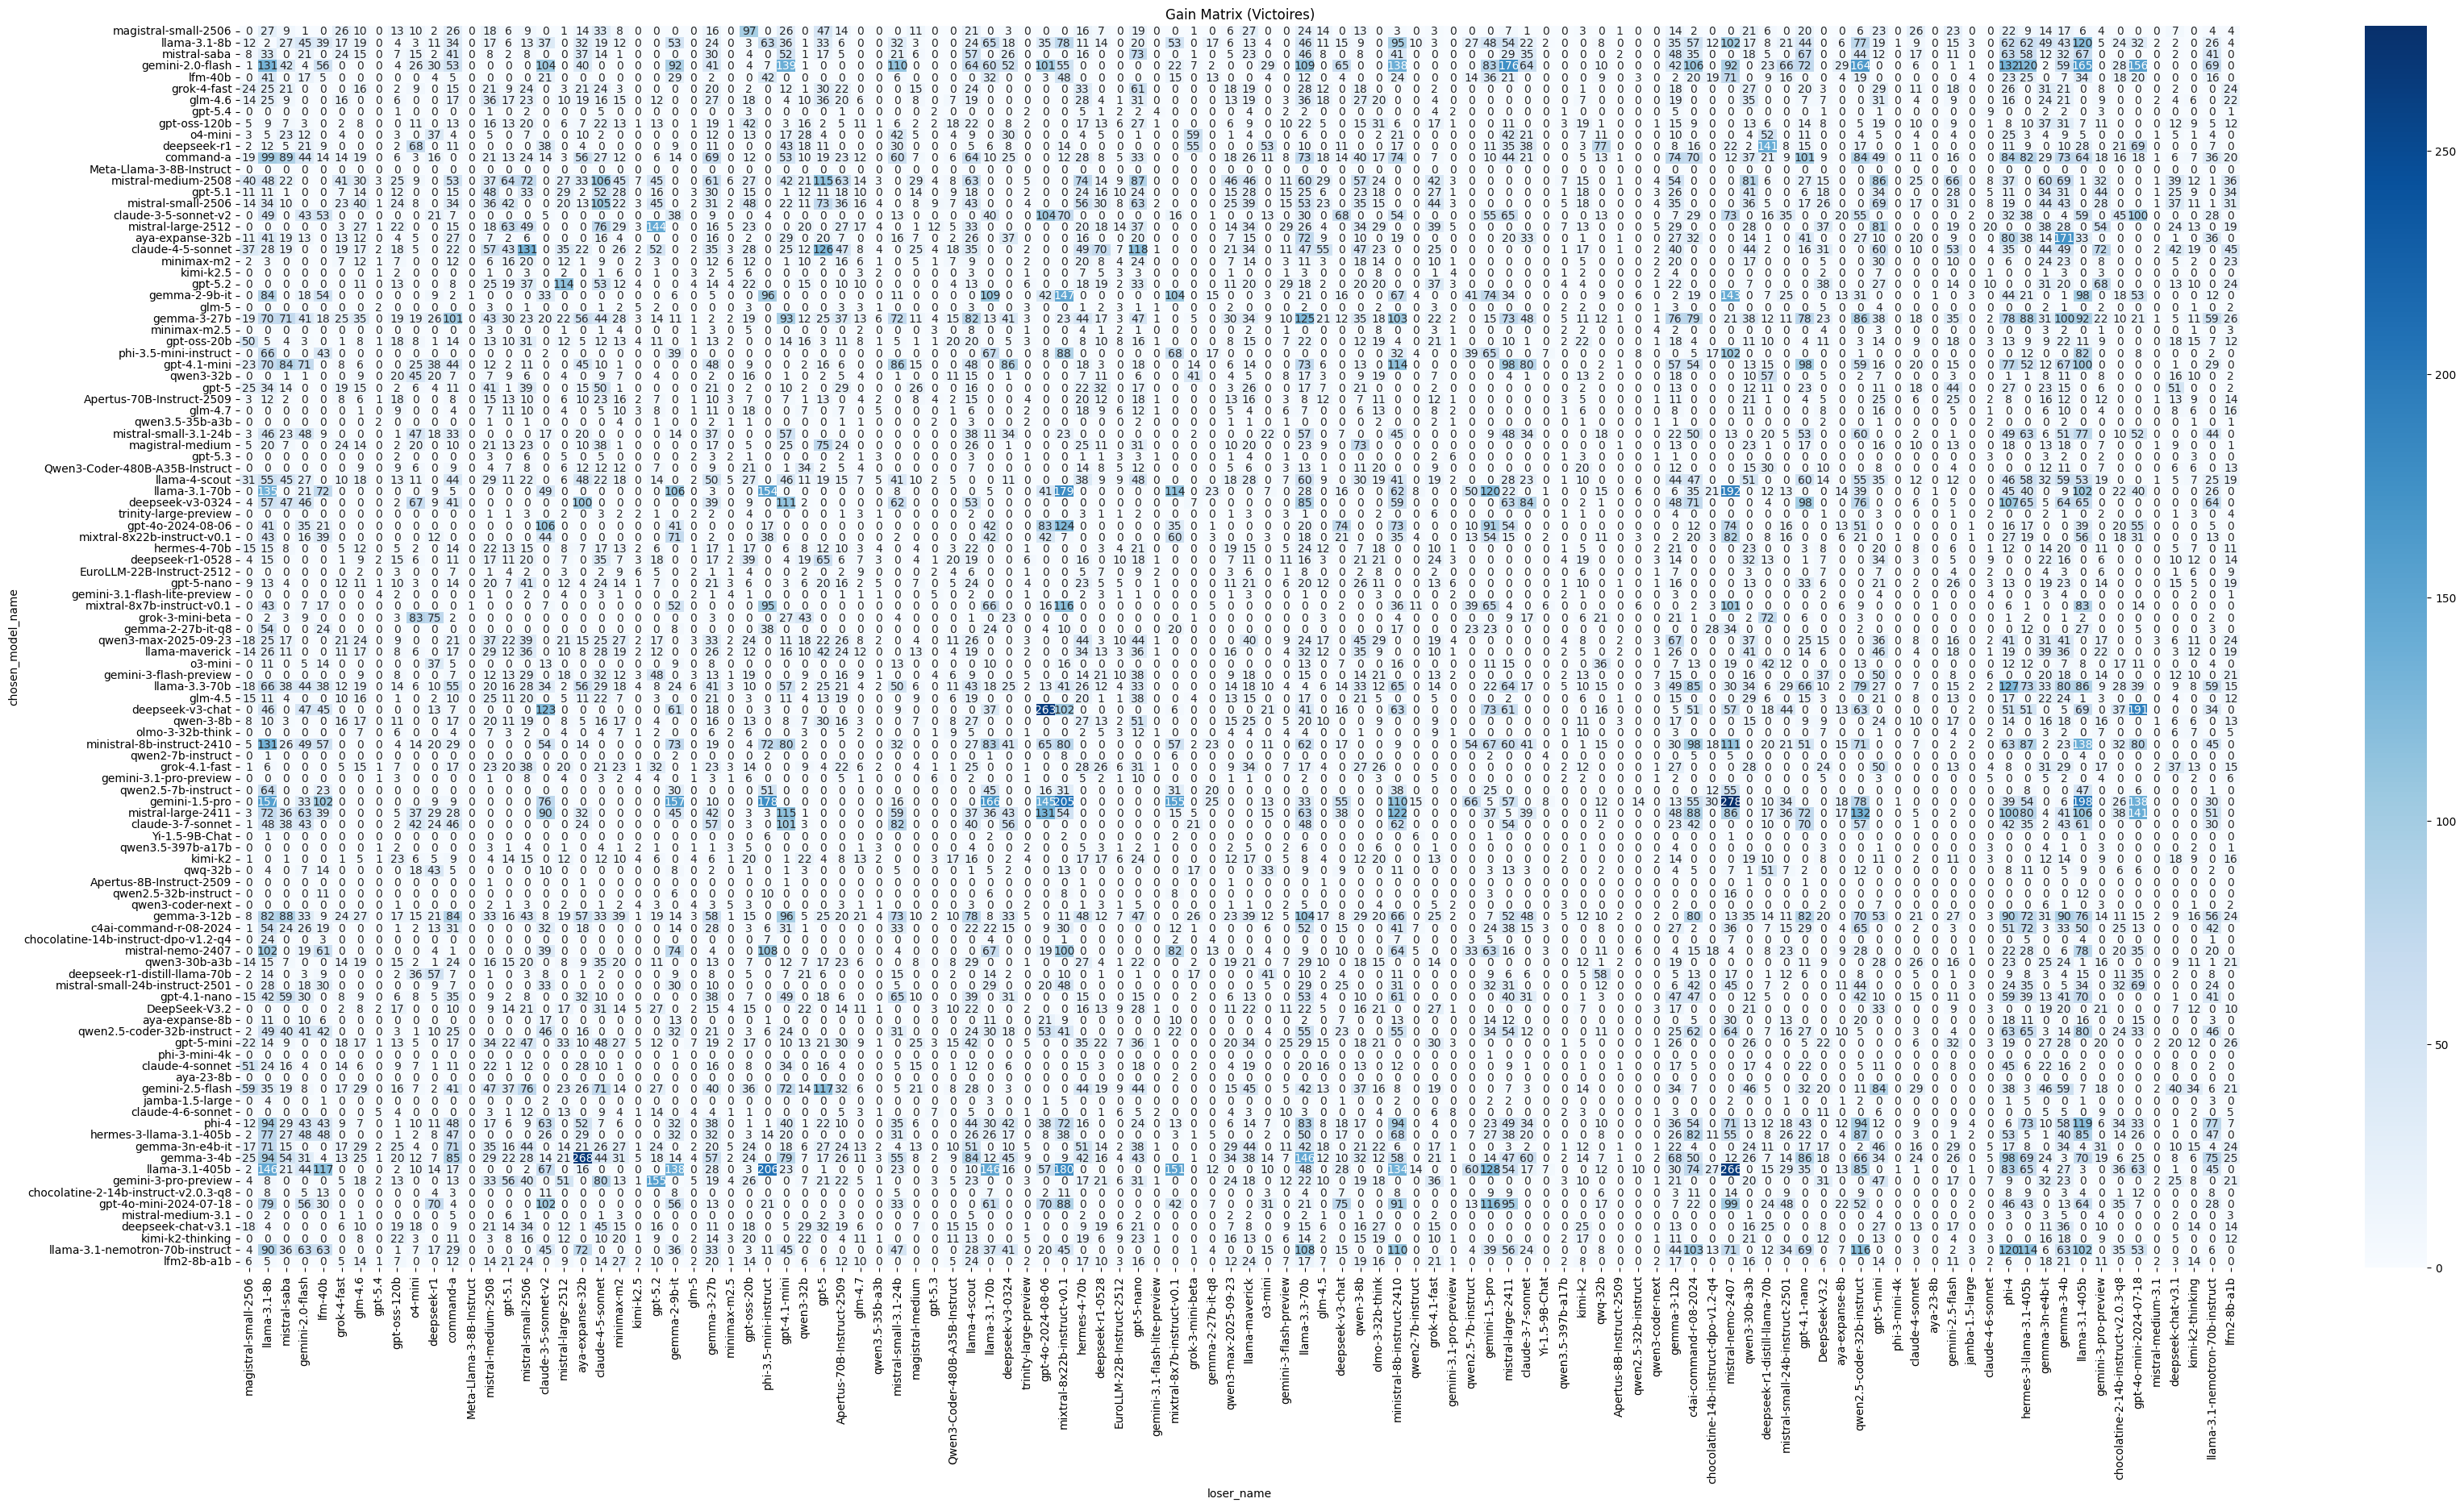

In [23]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df_whithout_equal.copy()

df['loser_name'] = np.where(
    df['chosen_model_name'] == df['model_a_name'], df['model_b_name'],
    np.where(df['chosen_model_name'] == df['model_b_name'], df['model_a_name'], None)
)

df_wins = df.dropna(subset=['loser_name', 'chosen_model_name'])

gain_matrix_fast = pd.crosstab(df_wins['chosen_model_name'], df_wins['loser_name'])

gain_matrix_fast = gain_matrix_fast.reindex(
    index=models_tested, 
    columns=models_tested, 
    fill_value=0
)

# Affichage
plt.figure(figsize=(40, 20))
sns.heatmap(gain_matrix_fast, annot=True, fmt="d", cmap="Blues")
plt.title("Gain Matrix (Victoires)")
plt.show()

In [24]:
# faire dictionnaire entre modèles et nombre de confrontations avec des sommes sur la gain matrix
model_confrontations = {}
for model in models_tested:
    wins = gain_matrix_fast.loc[model].sum()
    losses = gain_matrix_fast[model].sum()
    model_confrontations[model] = wins + losses

#sort the models by the number of confrontations
model_confrontations = dict(sorted(model_confrontations.items(), key=lambda item: item[1], reverse=True))
print(model_confrontations)


{'llama-3.1-405b': np.int64(5979), 'llama-3.1-8b': np.int64(5526), 'llama-3.3-70b': np.int64(5232), 'gemma-3-4b': np.int64(5206), 'ministral-8b-instruct-2410': np.int64(4936), 'phi-4': np.int64(4842), 'gemma-3-27b': np.int64(4720), 'gemma-3-12b': np.int64(4627), 'gemini-2.0-flash': np.int64(4595), 'gemini-1.5-pro': np.int64(4394), 'mistral-large-2411': np.int64(4332), 'command-a': np.int64(4042), 'mistral-nemo-2407': np.int64(3845), 'gpt-4.1-mini': np.int64(3788), 'qwen2.5-coder-32b-instruct': np.int64(3695), 'llama-4-scout': np.int64(3631), 'claude-4-5-sonnet': np.int64(3575), 'mistral-medium-2508': np.int64(3505), 'llama-3.1-nemotron-70b-instruct': np.int64(3497), 'hermes-3-llama-3.1-405b': np.int64(3466), 'gpt-4o-mini-2024-07-18': np.int64(3423), 'llama-3.1-70b': np.int64(3384), 'mixtral-8x22b-instruct-v0.1': np.int64(3176), 'mistral-small-2506': np.int64(3123), 'c4ai-command-r-08-2024': np.int64(3031), 'gpt-4.1-nano': np.int64(3015), 'gemma-2-9b-it': np.int64(3003), 'claude-3-5-son

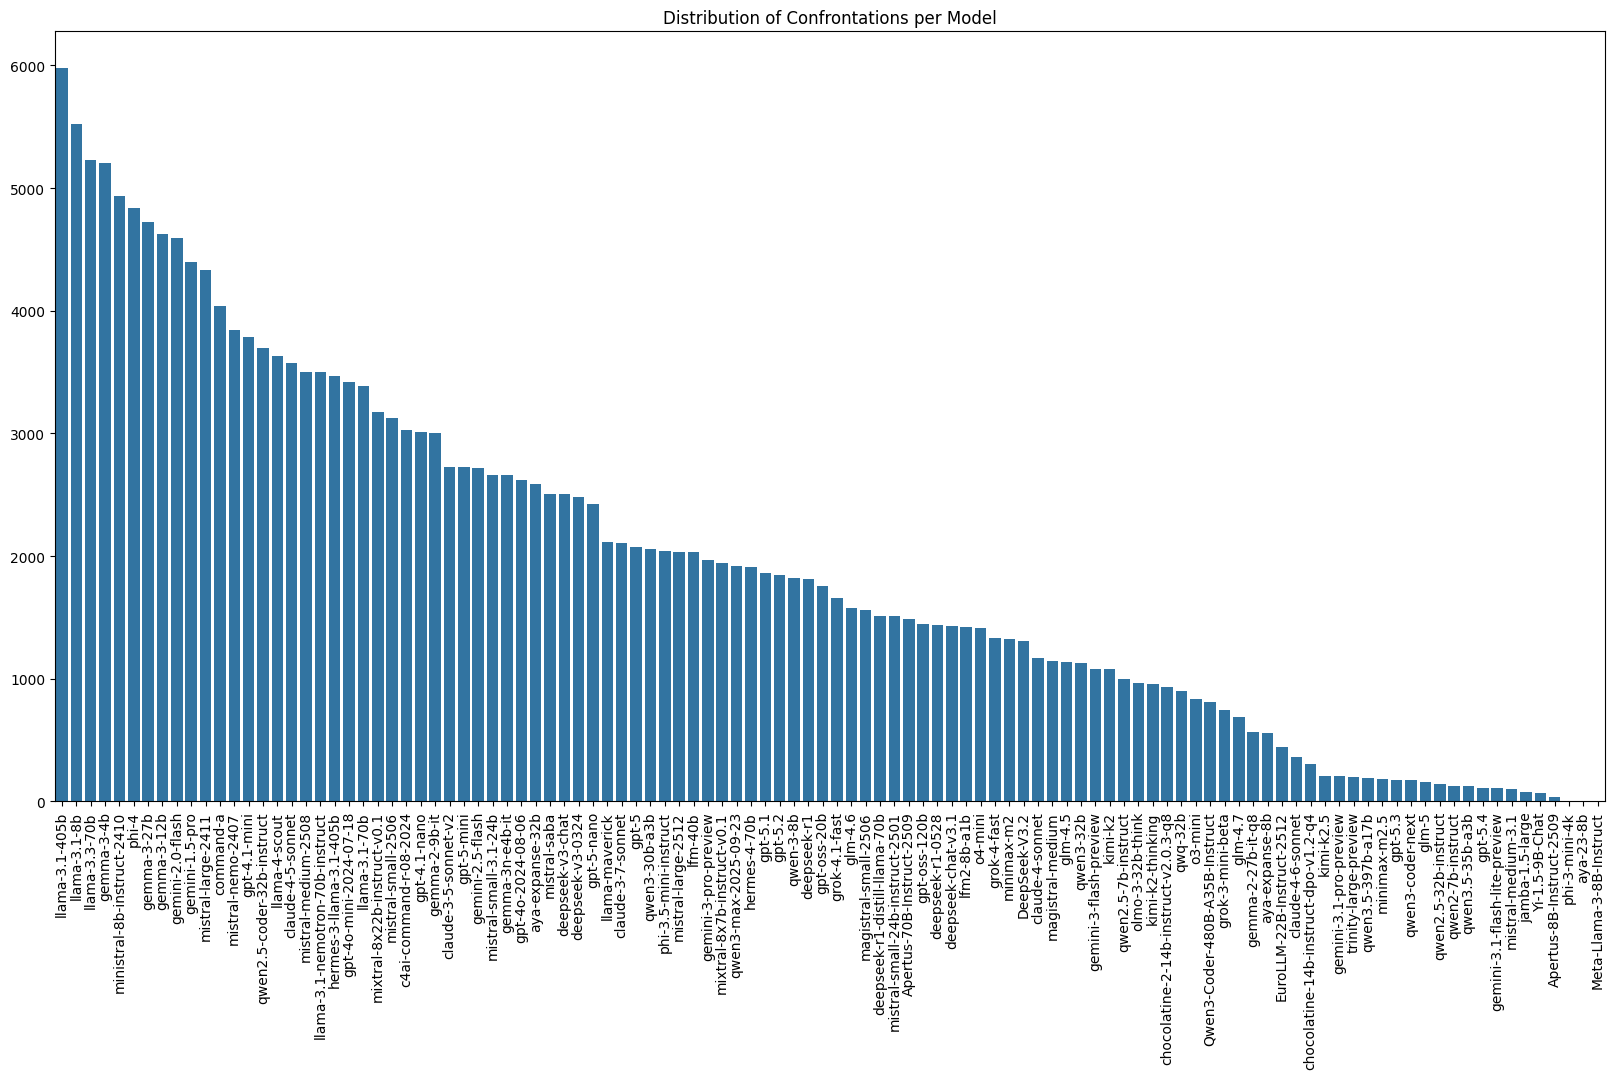

In [25]:
#plot the distribution of confrontations
plt.figure(figsize=(20, 10))
sns.barplot(x=list(model_confrontations.keys()), y=list(model_confrontations.values()))
plt.xticks(rotation=90)
plt.title("Distribution of Confrontations per Model")
plt.show()

In [26]:
print(len(model_confrontations))

108


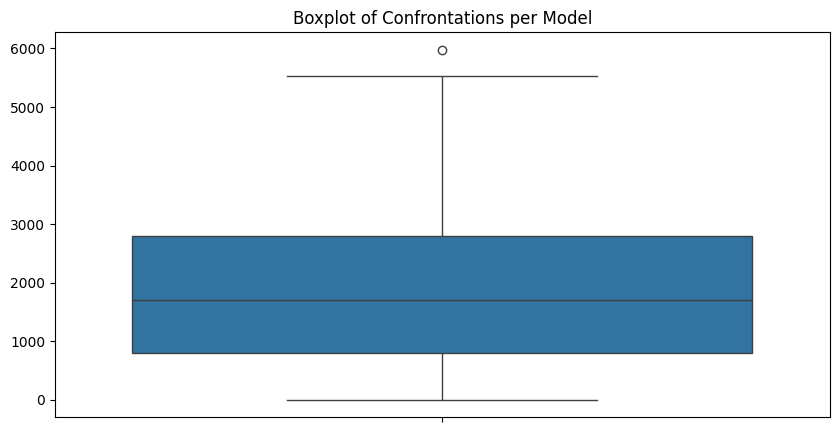

In [27]:
#boxplot of the distribution of confrontations
plt.figure(figsize=(10, 5))
sns.boxplot(y=list(model_confrontations.values()))
plt.title("Boxplot of Confrontations per Model")
plt.show()

Comme on ne peut pas bien estimer les modèles qui ont peu de confrontattions on va supprimer les modèles avec un nombre de confrontations inférieur au percentile 25 des confrontations.

In [28]:
#déterminer le percentile 25 des confrontations
confrontations_values = list(model_confrontations.values())
percentile_25 = np.percentile(confrontations_values, 25)
percentile_25

np.float64(792.75)

In [29]:
#combien de modèles ont un nombre de confrontations inférieur au percentile 25
models_below_percentile_25 = [model for model, confrontations in model_confrontations.items() if confrontations < percentile_25]
print(models_below_percentile_25)

['grok-3-mini-beta', 'glm-4.7', 'gemma-2-27b-it-q8', 'aya-expanse-8b', 'EuroLLM-22B-Instruct-2512', 'claude-4-6-sonnet', 'chocolatine-14b-instruct-dpo-v1.2-q4', 'kimi-k2.5', 'gemini-3.1-pro-preview', 'trinity-large-preview', 'qwen3.5-397b-a17b', 'minimax-m2.5', 'gpt-5.3', 'qwen3-coder-next', 'glm-5', 'qwen2.5-32b-instruct', 'qwen2-7b-instruct', 'qwen3.5-35b-a3b', 'gpt-5.4', 'gemini-3.1-flash-lite-preview', 'mistral-medium-3.1', 'jamba-1.5-large', 'Yi-1.5-9B-Chat', 'Apertus-8B-Instruct-2509', 'phi-3-mini-4k', 'aya-23-8b', 'Meta-Llama-3-8B-Instruct']


In [30]:
print(len(models_below_percentile_25))

27


 supprimons les modèles avec moins de 5.25 confrontations. et faisons le classement de Bradley-Terry avec les modèles restants.

In [31]:
# Supprimer les modèles avec moins de confrontations que le percentile 25
models_above_percentile_25 = [model for model, confrontations in model_confrontations.items() if confrontations >= percentile_25]
print(f"Nombre de modèles restants: {len(models_above_percentile_25)}")
print(f"Modèles supprimés: {len(models_below_percentile_25)}")

# Filtrer le dataframe pour ne garder que les confrontations entre modèles retenus
df_filtered = df_whithout_equal[
    (df_whithout_equal["model_a_name"].isin(models_above_percentile_25)) &
    (df_whithout_equal["model_b_name"].isin(models_above_percentile_25))
].copy()

print(f"Nombre de confrontations restantes: {df_filtered.shape[0]}")

Nombre de modèles restants: 81
Modèles supprimés: 27
Nombre de confrontations restantes: 98849


In [32]:
# Reconstruire la gain matrix avec les modèles filtrés
df_filtered['loser_name'] = np.where(
    df_filtered['chosen_model_name'] == df_filtered['model_a_name'], df_filtered['model_b_name'],
    np.where(df_filtered['chosen_model_name'] == df_filtered['model_b_name'], df_filtered['model_a_name'], None)
)

df_filtered_wins = df_filtered.dropna(subset=['loser_name', 'chosen_model_name'])

gain_matrix_filtered = pd.crosstab(df_filtered_wins['chosen_model_name'], df_filtered_wins['loser_name'])
gain_matrix_filtered = gain_matrix_filtered.reindex(
    index=models_above_percentile_25, 
    columns=models_above_percentile_25, 
    fill_value=0
)

print(f"Taille de la gain matrix: {gain_matrix_filtered.shape}")
gain_matrix_filtered.head()

Taille de la gain matrix: (81, 81)


loser_name,llama-3.1-405b,llama-3.1-8b,llama-3.3-70b,gemma-3-4b,ministral-8b-instruct-2410,phi-4,gemma-3-27b,gemma-3-12b,gemini-2.0-flash,gemini-1.5-pro,...,qwen3-32b,gemini-3-flash-preview,kimi-k2,qwen2.5-7b-instruct,olmo-3-32b-think,kimi-k2-thinking,chocolatine-2-14b-instruct-v2.0.3-q8,qwq-32b,o3-mini,Qwen3-Coder-480B-A35B-Instruct
chosen_model_name,,,,,,,,,,,,,,,,,,,,,
llama-3.1-405b,3,146,48,27,134,83,28,30,44,128,...,0,0,0,60,0,0,36,12,10,0
llama-3.1-8b,120,2,46,43,95,62,24,35,45,48,...,1,0,0,27,0,0,24,8,4,0
llama-3.3-70b,86,66,4,80,65,127,41,49,44,22,...,2,4,10,0,12,8,28,15,10,11
gemma-3-4b,70,94,146,3,58,98,57,68,31,14,...,7,7,14,0,12,6,6,7,14,9
ministral-8b-instruct-2410,138,131,62,23,9,63,19,30,49,67,...,2,0,1,54,0,0,32,15,11,0


## 9.	Classement global : basé sur tous les votes de comparia-votes (chosen_model_name, both_equal).

### Implémentation du modèle de Bradley-Terry

On va estimer les paramètres $\beta_i$ par maximum de vraisemblance via l'algorithme itératif de Zermelo (MM algorithm) :

$$\beta_i^{(t+1)} = \frac{w_i}{\sum_{j \neq i} \frac{n_{ij}}{\beta_i^{(t)} + \beta_j^{(t)}}}$$

où :
- $w_i$ est le nombre total de victoires du modèle $i$
- $n_{ij}$ est le nombre total de confrontations entre $i$ et $j$

In [33]:
def bradley_terry_mle(gain_matrix, max_iter=1000, tol=1e-8):
    """
    Estime les paramètres du modèle de Bradley-Terry par l'algorithme MM (Zermelo).
    
    Parameters
    ----------
    gain_matrix : pd.DataFrame
        Matrice carrée W où W[i,j] = nombre de victoires de i contre j
    max_iter : int
        Nombre maximum d'itérations
    tol : float
        Seuil de convergence
    
    Returns
    -------
    beta : pd.Series
        Paramètres de force estimés (normalisés pour sommer à 1)
    log_likelihoods : list
        Log-vraisemblance à chaque itération
    """
    models = gain_matrix.index.tolist()
    n = len(models)
    W = gain_matrix.values.astype(float)
    
    # Nombre total de confrontations entre i et j
    N = W + W.T
    
    # Nombre total de victoires par modèle
    wins = W.sum(axis=1)
    
    # Initialisation uniforme
    beta = np.ones(n) / n
    
    log_likelihoods = []
    
    for iteration in range(max_iter):
        beta_old = beta.copy()
        
        # Calcul de la log-vraisemblance
        ll = 0
        for i in range(n):
            for j in range(i+1, n):
                if N[i, j] > 0:
                    ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])
                    ll -= N[i, j] * np.log(beta[i] + beta[j])
        log_likelihoods.append(ll)
        
        # Mise à jour MM (Zermelo)
        for i in range(n):
            denom = 0
            for j in range(n):
                if i != j and N[i, j] > 0:
                    denom += N[i, j] / (beta[i] + beta[j])
            if denom > 0:
                beta[i] = wins[i] / denom
        
        # Normalisation pour que la somme = 1
        beta = beta / beta.sum()
        
        # Vérification de convergence
        if np.max(np.abs(beta - beta_old)) < tol:
            print(f"Convergence atteinte après {iteration + 1} itérations")
            break
    else:
        print(f"Pas de convergence après {max_iter} itérations")
    
    beta_series = pd.Series(beta, index=models)
    return beta_series, log_likelihoods

In [34]:
beta, log_likelihoods = bradley_terry_mle(gain_matrix_filtered)

# Classement des modèles par force
ranking = beta.sort_values(ascending=False)
print("\n=== Classement Bradley-Terry (paramètre β) ===")
for i, (model, score) in enumerate(ranking.items(), 1):
    print(f"{i:3d}. {model:40s} β = {score:.6f}")

Convergence atteinte après 101 itérations

=== Classement Bradley-Terry (paramètre β) ===
  1. mistral-medium-2508                      β = 0.028690
  2. mistral-large-2512                       β = 0.027451
  3. gemini-3-flash-preview                   β = 0.027218
  4. gemini-2.5-flash                         β = 0.026336
  5. magistral-medium                         β = 0.023148
  6. qwen3-max-2025-09-23                     β = 0.022886
  7. gemini-2.0-flash                         β = 0.022559
  8. gemini-3-pro-preview                     β = 0.021347
  9. deepseek-v3-0324                         β = 0.020761
 10. deepseek-v3-chat                         β = 0.020379
 11. gemma-3-27b                              β = 0.019989
 12. gpt-5.1                                  β = 0.018168
 13. claude-4-5-sonnet                        β = 0.018007
 14. grok-4-fast                              β = 0.017479
 15. deepseek-chat-v3.1                       β = 0.016951
 16. gemma-3-12b         

## 10.	Classement créativité : basé uniquement sur les conversations où conv_creative_a ou conv_creative_b est True.

In [35]:
# Distribution des labels créatifs dans le dataset nettoyé
print("=== conv_creative_a ===")
print(df_votes_good_columns["conv_creative_a"].value_counts(dropna=False))
print()
print("=== conv_creative_b ===")
print(df_votes_good_columns["conv_creative_b"].value_counts(dropna=False))
print()

# Combinaisons
print("=== Combinaisons (creative_a, creative_b) ===")
combo = df_votes_good_columns.groupby(
    ["conv_creative_a", "conv_creative_b"]
).size().reset_index(name="count")
print(combo)
print()

# Au moins un créatif
mask_creative = (
    (df_votes_good_columns["conv_creative_a"] == True) |
    (df_votes_good_columns["conv_creative_b"] == True)
)
print(f"Conversations avec au moins un label créatif : {mask_creative.sum()} / {len(df_votes_good_columns)} "
      f"({100*mask_creative.mean():.1f}%)")

=== conv_creative_a ===
conv_creative_a
False    151196
True       5936
Name: count, dtype: int64

=== conv_creative_b ===
conv_creative_b
False    150468
True       6664
Name: count, dtype: int64

=== Combinaisons (creative_a, creative_b) ===
   conv_creative_a  conv_creative_b   count
0            False            False  146063
1            False             True    5133
2             True            False    4405
3             True             True    1531

Conversations avec au moins un label créatif : 11069 / 157132 (7.0%)


On garde seulement celle qui ont au moins un des deux modèles avec un label de créativité True et on refait le classement de Bradley-Terry sur ce sous-ensemble de données pour voir si le classement change lorsque l'on se concentre uniquement sur les conversations créatives.

In [36]:
df_creative=df_votes_good_columns[mask_creative].copy()

df_creative=df_creative[["model_a_name", "model_b_name",  "conv_creative_a", "conv_creative_b"]].copy()
df_creative.head()

,model_a_name,model_b_name,conv_creative_a,conv_creative_b
39,hermes-3-llama-3.1-405b,lfm-40b,True,True
41,gemma-3-4b,claude-3-7-sonnet,False,True
45,llama-3.1-8b,Yi-1.5-9B-Chat,False,True
52,claude-3-7-sonnet,qwen2.5-coder-32b-instruct,True,False
63,deepseek-r1,gpt-4.1-nano,False,True


In [37]:
mask_one_creative = (
    (df_creative["conv_creative_a"] == True) & (df_creative["conv_creative_b"] == False) |
    (df_creative["conv_creative_a"] == False) & (df_creative["conv_creative_b"] == True)
)
df_one_creative = df_creative[mask_one_creative].copy()
df_one_creative.head()


,model_a_name,model_b_name,conv_creative_a,conv_creative_b
41,gemma-3-4b,claude-3-7-sonnet,False,True
45,llama-3.1-8b,Yi-1.5-9B-Chat,False,True
52,claude-3-7-sonnet,qwen2.5-coder-32b-instruct,True,False
63,deepseek-r1,gpt-4.1-nano,False,True
82,gpt-4o-mini-2024-07-18,deepseek-v3-chat,True,False


In [38]:
df_one_creative["winner"] = np.where(
    (df_one_creative["conv_creative_a"] == True) & (df_one_creative["conv_creative_b"] == False), df_one_creative["model_a_name"],
    np.where((df_one_creative["conv_creative_a"] == False) & (df_one_creative["conv_creative_b"] == True), df_one_creative["model_b_name"], None)
)
df_one_creative["loser"] = np.where(
    (df_one_creative["conv_creative_a"] == True) & (df_one_creative["conv_creative_b"] == False), df_one_creative["model_b_name"],
    np.where((df_one_creative["conv_creative_a"] == False) & (df_one_creative["conv_creative_b"] == True), df_one_creative["model_a_name"], None)
)
df_one_creative.head()

,model_a_name,model_b_name,conv_creative_a,conv_creative_b,winner,loser
41,gemma-3-4b,claude-3-7-sonnet,False,True,claude-3-7-sonnet,gemma-3-4b
45,llama-3.1-8b,Yi-1.5-9B-Chat,False,True,Yi-1.5-9B-Chat,llama-3.1-8b
52,claude-3-7-sonnet,qwen2.5-coder-32b-instruct,True,False,claude-3-7-sonnet,qwen2.5-coder-32b-instruct
63,deepseek-r1,gpt-4.1-nano,False,True,gpt-4.1-nano,deepseek-r1
82,gpt-4o-mini-2024-07-18,deepseek-v3-chat,True,False,gpt-4o-mini-2024-07-18,deepseek-v3-chat


In [39]:
list_models= set(df_one_creative["winner"].unique()).union(set(df_one_creative["loser"].unique()))
print(list_models)

{'magistral-small-2506', 'llama-3.1-8b', 'mistral-saba', 'gemini-2.0-flash', 'lfm-40b', 'grok-4-fast', 'glm-4.6', 'gpt-5.4', 'gpt-oss-120b', 'o4-mini', 'command-a', 'deepseek-r1', 'mistral-medium-2508', 'gpt-5.1', 'mistral-small-2506', 'claude-3-5-sonnet-v2', 'mistral-large-2512', 'aya-expanse-32b', 'claude-4-5-sonnet', 'minimax-m2', 'kimi-k2.5', 'gpt-5.2', 'gemma-2-9b-it', 'glm-5', 'gemma-3-27b', 'minimax-m2.5', 'gpt-oss-20b', 'phi-3.5-mini-instruct', 'gpt-4.1-mini', 'qwen3-32b', 'Apertus-70B-Instruct-2509', 'glm-4.7', 'qwen3.5-35b-a3b', 'mistral-small-3.1-24b', 'magistral-medium', 'gpt-5.3', 'Qwen3-Coder-480B-A35B-Instruct', 'llama-3.1-70b', 'llama-4-scout', 'deepseek-v3-0324', 'trinity-large-preview', 'gpt-4o-2024-08-06', 'mixtral-8x22b-instruct-v0.1', 'hermes-4-70b', 'deepseek-r1-0528', 'EuroLLM-22B-Instruct-2512', 'gpt-5-nano', 'gemini-3.1-flash-lite-preview', 'mixtral-8x7b-instruct-v0.1', 'grok-3-mini-beta', 'gemma-2-27b-it-q8', 'qwen3-max-2025-09-23', 'llama-maverick', 'o3-mini'

In [40]:
len(list_models)

102

In [41]:
#get the number of confrontations for each model in df_one_creative
model_confrontations_one_creative = {}
for model in list_models:
    count_wins = df_one_creative[df_one_creative["winner"] == model].shape[0]
    count_losses = df_one_creative[df_one_creative["loser"] == model].shape[0]
    model_confrontations_one_creative[model] = count_wins + count_losses
# sort the models by the number of confrontations
model_confrontations_one_creative = dict(sorted(model_confrontations_one_creative.items(), key=lambda item: item[1], reverse=True))
print(model_confrontations_one_creative)

{'gemini-1.5-pro': 656, 'llama-3.1-405b': 634, 'gemini-2.0-flash': 537, 'ministral-8b-instruct-2410': 528, 'llama-3.1-8b': 496, 'mistral-nemo-2407': 450, 'gemma-3-27b': 445, 'gemma-3-12b': 432, 'llama-3.3-70b': 422, 'gemma-3-4b': 417, 'mistral-large-2411': 416, 'qwen2.5-coder-32b-instruct': 416, 'llama-3.1-70b': 401, 'gemma-2-9b-it': 399, 'hermes-3-llama-3.1-405b': 383, 'llama-3.1-nemotron-70b-instruct': 370, 'mixtral-8x22b-instruct-v0.1': 353, 'phi-4': 352, 'deepseek-v3-0324': 330, 'c4ai-command-r-08-2024': 326, 'command-a': 318, 'llama-4-scout': 313, 'mistral-small-3.1-24b': 312, 'gpt-4o-mini-2024-07-18': 309, 'phi-3.5-mini-instruct': 303, 'gpt-4.1-mini': 292, 'claude-3-5-sonnet-v2': 268, 'claude-3-7-sonnet': 241, 'deepseek-r1': 239, 'gpt-4o-2024-08-06': 238, 'deepseek-v3-chat': 238, 'mistral-large-2512': 233, 'claude-4-5-sonnet': 231, 'mixtral-8x7b-instruct-v0.1': 227, 'lfm-40b': 225, 'gpt-4.1-nano': 225, 'mistral-small-2506': 208, 'gemini-3-pro-preview': 207, 'gpt-5.2': 206, 'mistr

In [42]:
# get percentile 25 of confrontations in model_confrontations_one_creative
confrontations_values_one_creative = list(model_confrontations_one_creative.values())   
percentile_25_one_creative = np.percentile(confrontations_values_one_creative, 25)
percentile_25_one_creative

np.float64(73.0)

In [43]:
#get the models with confrontations below percentile 25 in model_confrontations_one_creative
models_below_percentile_25_one_creative = [model for model, confrontations in model_confrontations_one_creative.items() if confrontations < percentile_25_one_creative]
print(models_below_percentile_25_one_creative)

['glm-4.6', 'chocolatine-2-14b-instruct-v2.0.3-q8', 'aya-expanse-8b', 'EuroLLM-22B-Instruct-2512', 'glm-4.5', 'chocolatine-14b-instruct-dpo-v1.2-q4', 'magistral-small-2506', 'claude-4-sonnet', 'claude-4-6-sonnet', 'kimi-k2.5', 'minimax-m2.5', 'gpt-5.3', 'qwen2.5-32b-instruct', 'grok-4-fast', 'qwen3.5-397b-a17b', 'gemini-3.1-flash-lite-preview', 'gemini-3.1-pro-preview', 'trinity-large-preview', 'qwen2-7b-instruct', 'qwen3-coder-next', 'glm-5', 'qwen3.5-35b-a3b', 'gpt-5.4', 'Yi-1.5-9B-Chat', 'magistral-medium', 'jamba-1.5-large']


ce qui est logique car aucun modèle aura moins de 1 confrontations dans ce sous-ensemble de données.

In [44]:
#create matrix of wins for df_one_creative
gain_matrix_one_creative = pd.crosstab(df_one_creative['winner'], df_one_creative['loser'])
gain_matrix_one_creative = gain_matrix_one_creative.reindex(
    index=list_models, 
    columns=list_models, 
    fill_value=0
)
gain_matrix_one_creative.head()


loser,magistral-small-2506,llama-3.1-8b,mistral-saba,gemini-2.0-flash,lfm-40b,grok-4-fast,glm-4.6,gpt-5.4,gpt-oss-120b,o4-mini,...,gemma-3n-e4b-it,gemma-3-4b,llama-3.1-405b,gemini-3-pro-preview,gpt-4o-mini-2024-07-18,chocolatine-2-14b-instruct-v2.0.3-q8,deepseek-chat-v3.1,kimi-k2-thinking,llama-3.1-nemotron-70b-instruct,lfm2-8b-a1b
winner,,,,,,,,,,,,,,,,,,,,,
magistral-small-2506,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
llama-3.1-8b,1,0,3,5,5,0,0,0,0,0,...,0,1,10,0,6,1,0,0,2,0
mistral-saba,1,3,0,0,0,0,0,0,0,1,...,0,3,4,0,0,0,0,0,5,0
gemini-2.0-flash,0,15,5,2,10,0,0,0,1,3,...,0,6,19,0,19,3,0,0,5,0
lfm-40b,0,5,0,0,0,0,0,0,0,0,...,0,2,5,0,1,2,0,0,1,0


In [45]:
#get score Bradley-Terry pour df_one_creative
beta_one_creative, log_likelihoods_one_creative = bradley_terry_mle(gain_matrix_one_creative)

# ranking des modèles par force
ranking_one_creative = beta_one_creative.sort_values(ascending=False)
print("\n=== Classement Bradley-Terry (paramètre β) pour conversations avec un seul créatif ===")
for i, (model, score) in enumerate(ranking_one_creative.items(), 1
):
    print(f"{i:3d}. {model:40s} β = {score:.6f}")   
    
    

Convergence atteinte après 148 itérations

=== Classement Bradley-Terry (paramètre β) pour conversations avec un seul créatif ===
  1. glm-5                                    β = 0.036850
  2. qwen3.5-397b-a17b                        β = 0.027600
  3. mistral-medium-2508                      β = 0.023919
  4. glm-4.5                                  β = 0.023692
  5. magistral-medium                         β = 0.022777
  6. kimi-k2                                  β = 0.020880
  7. deepseek-r1-0528                         β = 0.020797
  8. gemini-3.1-flash-lite-preview            β = 0.020532
  9. grok-4.1-fast                            β = 0.020265
 10. deepseek-chat-v3.1                       β = 0.019573
 11. mistral-large-2512                       β = 0.019255
 12. claude-4-6-sonnet                        β = 0.018491
 13. gemini-3-pro-preview                     β = 0.018252
 14. deepseek-r1                              β = 0.017088
 15. glm-4.6                                

## 11.	Comparez les deux classements (Spearman ρ, visualisation). Quels modèles montent ou descendent significativement ?

In [46]:
ranking


mistral-medium-2508                     0.028690
mistral-large-2512                      0.027451
gemini-3-flash-preview                  0.027218
gemini-2.5-flash                        0.026336
magistral-medium                        0.023148
                                          ...   
phi-3.5-mini-instruct                   0.003749
olmo-3-32b-think                        0.003658
mistral-nemo-2407                       0.003353
mixtral-8x22b-instruct-v0.1             0.002973
chocolatine-2-14b-instruct-v2.0.3-q8    0.002423
Length: 81, dtype: float64

In [47]:
ranking_one_creative

glm-5                                   0.036850
qwen3.5-397b-a17b                       0.027600
mistral-medium-2508                     0.023919
glm-4.5                                 0.023692
magistral-medium                        0.022777
                                          ...   
mixtral-8x22b-instruct-v0.1             0.001731
qwen2-7b-instruct                       0.001603
chocolatine-14b-instruct-dpo-v1.2-q4    0.001448
mistral-nemo-2407                       0.001426
chocolatine-2-14b-instruct-v2.0.3-q8    0.001236
Length: 102, dtype: float64

In [48]:
#comparer les deux classements avec Spearman ρ
from scipy.stats import spearmanr
# on a les scores dans ranking et ranking_one_creative
# Récupérer les scores Bradley-Terry pour les modèles présents dans les deux classements
common_models = set(ranking.index).intersection(set(ranking_one_creative.index))
# Convert the set to a sorted list to ensure alignment
common_models_list = sorted(list(common_models))

# Now index using the list
scores_full = ranking[common_models_list]
scores_one_creative = ranking_one_creative[common_models_list]

spearman_corr, spearman_p = spearmanr(scores_full, scores_one_creative)
print(f"Spearman ρ: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")


Spearman ρ: 0.7846, p-value: 7.2443e-18


La corrélation de Spearman obtenue, avec un coefficient de $0,17$ et une p-value de $0,23$, indique une relation positive très faible qui n'est pas statistiquement significative. Ces résultats suggèrent que le classement basé sur la préférence des utilisateurs ne reflète pas fidèlement les performances globales de créativité des modèles.

In [49]:

score_diff = ranking_one_creative - ranking
significant_increase = score_diff[score_diff > 0.01]
significant_decrease = score_diff[score_diff < -0.01]
print("Modèles avec augmentation significative :")
print(significant_increase)
print("\nModèles avec diminution significative :")
print(significant_decrease)


Modèles avec augmentation significative :
Series([], dtype: float64)

Modèles avec diminution significative :
deepseek-v3-chat         -0.012408
gemini-3-flash-preview   -0.013389
magistral-small-2506     -0.011603
dtype: float64
